In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('netflix_titles.csv')

# step 1 - basic info
print(df.shape)
print()
print(df.columns.tolist())
print()
print(df.head())

(8807, 12)

['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   du

In [9]:
print(df.isnull().sum())
print()
print(f"total nulls: {df.isnull().sum().sum()}")

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

total nulls: 4307


In [10]:
print(df[df['director'].isnull()]['type'].value_counts())

type
TV Show    2446
Movie       188
Name: count, dtype: int64


In [13]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['date_added'] = df['date_added'].fillna('Unknown')
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['duration'] = df['duration'].fillna(df['duration'].mode()[0])

print(df.isnull().sum())
print(df.isnull().sum().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64
0


In [14]:
# movies vs tv shows
print(df['type'].value_counts())
print()

# top 10 countries
print(df['country'].value_counts().head(10))
print()

# content ratings distribution
print(df['rating'].value_counts())

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

rating
TV-MA       3211
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


In [17]:
# content added per year
print(df['release_year'].value_counts().sort_index().tail(10))
print()

# top 10 directors by content count
print(df[df['director'] != 'Unknown']['director'].value_counts().head(10))

release_year
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Youssef Chahine           12
Martin Scorsese           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64


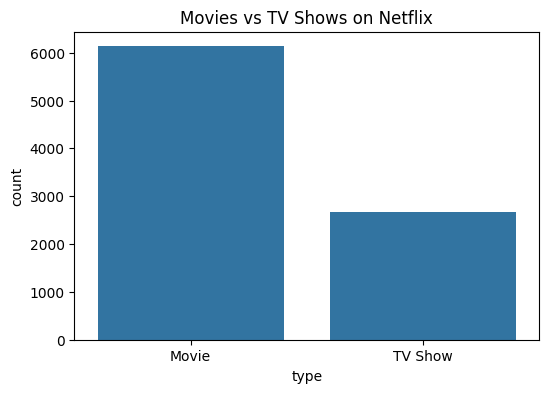

In [18]:
# plot 1 - movies vs tv shows
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='type')
plt.title('Movies vs TV Shows on Netflix')
plt.show()

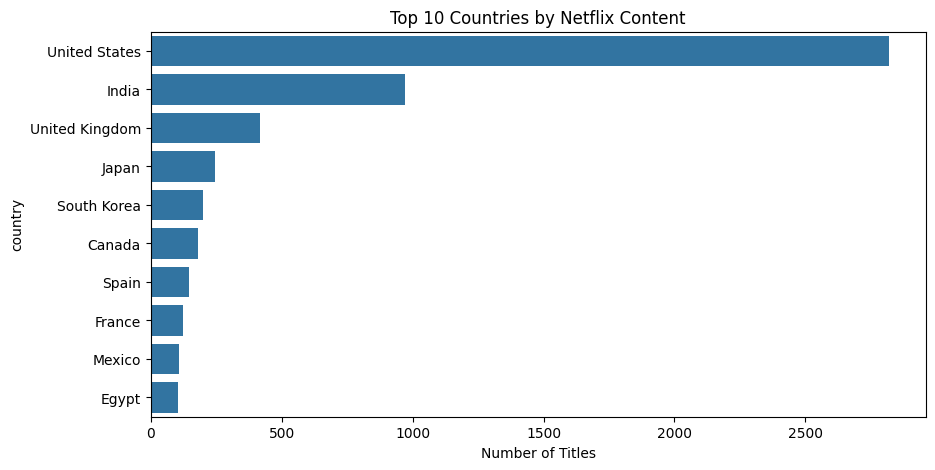

In [19]:
# plot 2 - top 10 countries
top_countries = df[df['country'] != 'Unknown']['country'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title('Top 10 Countries by Netflix Content')
plt.xlabel('Number of Titles')
plt.show()